In [4]:
visualization_target = input("INPUT 'visualization_target RUN_ID'(e.g., run_id_6): ")
model_in_run = input("INPUT 'model_in_run'(e.g., bert_based, lda, tag): ")

In [5]:
from gc import collect

import pickle
import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from lib.visualization.distribution_collector import (collect_topic_distributions,
                                get_top_and_bottom_topics,
                                extract_specific_topics,
                                collect_tag_distributions,
                                collect_top_bottom_tags)
# from constants import CONSTANTS
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib as mpl

import psycopg2
import pandas as pd
import numpy as np
from lib.utils.statistics import *
# import config.config as conf
from datetime import datetime
import re
# 포뮬러 구성
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd
import matplotlib as mpl
import lib.visualization.font_setting as font_setting
mpl.rcParams['font.family'] = font_setting.init_font()

from setting_for_sda.path_setting import path_list
from setting_for_sda.date_setting import Date_Setting


Helvetica33-ExtendedThin /home/mghan/.fonts/Helvetica/Helvetica Extended Thin.ttf
Registered font name: Helvetica33-ExtendedThin


In [6]:
viz_dir = f'{path_list["data_root_dir"]}/result/{model_in_run}/{visualization_target}'
data_dir = f"{viz_dir}/data"
option_dict = load_json(f"{viz_dir}/option.json")


output_dir = './fig/'
date_range = 'Weekly'

std_date = datetime.strptime(Date_Setting.chatgpt_release_date, "%Y.%m.%d")
# pre_std_date = datetime.datetime(2021, 12, 1)


In [7]:
df = load_df(data_dir, ['cdate' , 'id' , 'tag', 'cnt', 'tot_cnt', 'pct'])

In [9]:
df.head(20)

,cdate,id,tag,cnt,tot_cnt,pct
0,2022-07-06,72883378,python-3.x,1,2,0.500000
1,2022-07-06,72883378,try-except,1,2,0.500000
2,2022-07-06,72883390,django,1,2,0.500000
3,2022-07-06,72883390,django-rest-framework,1,2,0.500000
4,2022-07-06,72883396,string,1,2,0.500000
5,2022-07-06,72883396,line-breaks,1,2,0.500000
6,2022-07-06,72883399,pygame,1,1,1.000000
7,2022-07-06,72883431,pandas,1,3,0.333333
8,2022-07-06,72883431,dataframe,1,3,0.333333
9,2022-07-06,72883431,dictionary,1,3,0.333333


In [10]:
df['cdate'] = pd.to_datetime(df['cdate'], format="%Y-%m-%d")
df['rel_week'] = np.floor((df['cdate']-std_date).dt.days/7)

In [11]:
proportion_dict = dict()
proportion_dict = collect_top_bottom_tags(df)

In [12]:
proportion_dict

{'Top 20% Tags':      rel_week   pct_pct
 0       -53.0  0.996141
 1       -52.0  0.997285
 2       -51.0  0.995803
 3       -50.0  0.995928
 4       -49.0  0.996921
 ..        ...       ...
 205     152.0  0.932099
 206     153.0  0.910714
 207     154.0  0.926692
 208     155.0  0.932749
 209     156.0  0.943939
 
 [210 rows x 2 columns],
 'Bottom 20% Tags':      rel_week   pct_pct
 0       -53.0  0.003859
 1       -52.0  0.002715
 2       -51.0  0.004197
 3       -50.0  0.004072
 4       -49.0  0.003079
 ..        ...       ...
 205     152.0  0.004321
 206     153.0  0.004167
 207     154.0  0.013158
 208     155.0  0.008772
 209     156.0  0.006061
 
 [210 rows x 2 columns]}

In [13]:
color_list = ["#4C704C", "#A3C9A8"]

In [14]:
proportion_dict.keys()

dict_keys(['Top 20% Tags', 'Bottom 20% Tags'])

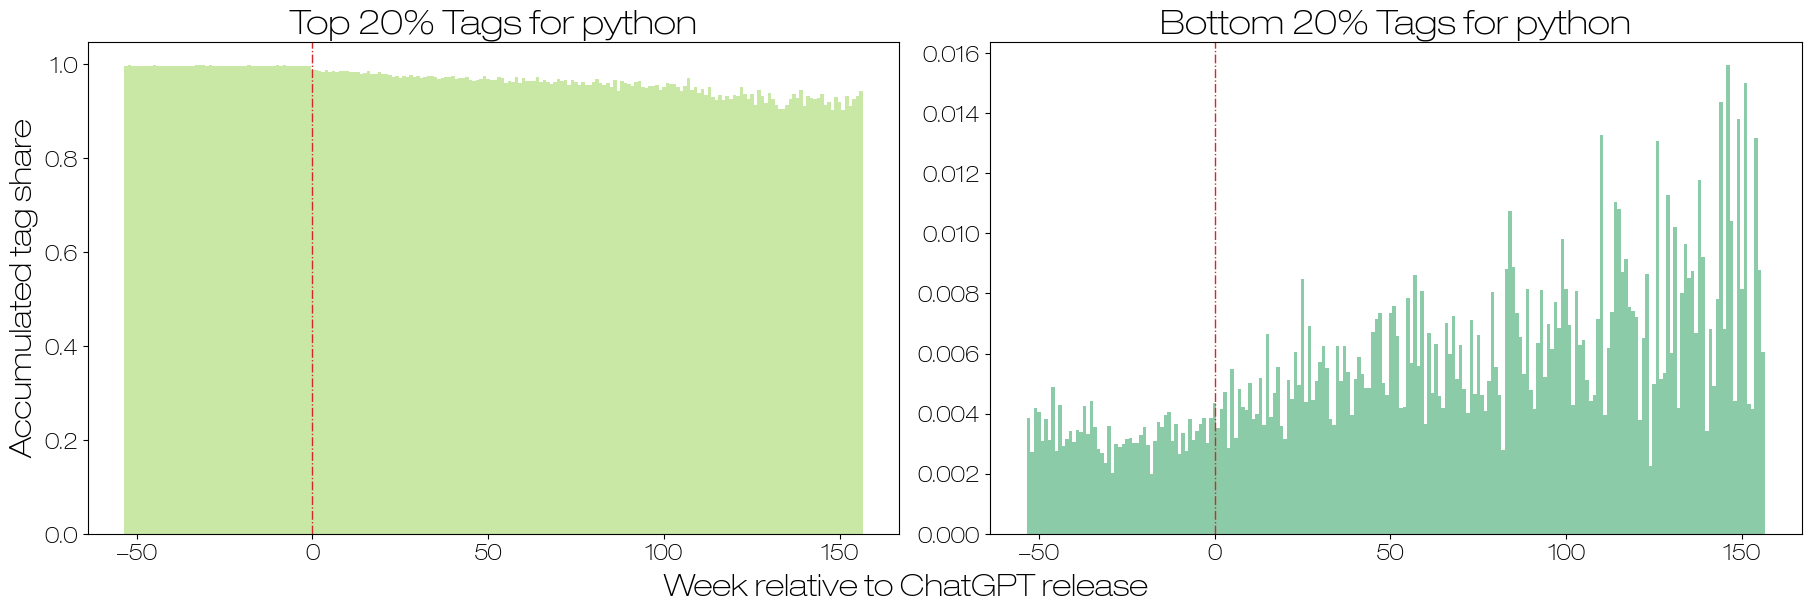

In [35]:
sharey = False ## 또는 sharey=False
sharex = True ## 또는 sharex=False

fig, axs = plt.subplots(1, 2, figsize = (18, 6), constrained_layout=True)
alpha_list = [0.6, 0.5]
color_list = ["#a6d96a", "#1a9850"]

for idx, (title, proportion) in enumerate(proportion_dict.items()):
    n_len = len(proportion_dict.items())
    rel_week = list(proportion['rel_week'])
    values = list(proportion['pct_pct'])


    axs[idx].bar(rel_week, values, color=color_list[idx], width=1.0, align='center', alpha=alpha_list[idx]
    )
    axs[idx].axvline(x=0, color='tab:red', linestyle='-.', linewidth=1)

    if idx ==2 :
        axs[idx].set_ylim(0.85, 1.0)
        axs[idx].set_yticks(np.arange(0.85, 1.01, 0.05))

    axs[idx].set_title(f'{title} for {option_dict["selected_tags"]}', fontsize=25)
    axs[idx].tick_params(axis='x', labelsize=16)
    axs[idx].tick_params(axis='y', labelsize=16)



axs[0].set_ylabel("Accumulated tag share", fontsize = 22)

fig.supxlabel("Week relative to ChatGPT release", fontsize=22) 
plt.savefig(f"{output_dir}C_Result_Fig2_1.png", dpi=300, bbox_inches='tight')
plt.show();

In [16]:
df

,cdate,id,tag,cnt,tot_cnt,pct,rel_week
0,2022-07-06,72883378,python-3.x,1,2,0.500000,-21.0
1,2022-07-06,72883378,try-except,1,2,0.500000,-21.0
2,2022-07-06,72883390,django,1,2,0.500000,-21.0
3,2022-07-06,72883390,django-rest-framework,1,2,0.500000,-21.0
4,2022-07-06,72883396,string,1,2,0.500000,-21.0
...,...,...,...,...,...,...,...
964578,2024-12-29,79316243,subplot,1,3,0.333333,108.0
964579,2024-12-29,79316269,oop,1,1,1.000000,108.0
964580,2024-12-29,79316278,python-3.9,1,1,1.000000,108.0
964581,2024-12-29,79316309,recursion,1,1,1.000000,108.0


In [18]:
# std_date = datetime.datetime(2022, 11, 30)
# tag_distribution_dict = dict()


tot_df = df.groupby(['rel_week'])['pct'].sum().reset_index(name='tot_pct')
tag_dis_by_df = df.groupby(['rel_week', 'tag'])['cnt'].sum().reset_index(name = 'pct')

df_proportion = pd.merge(tag_dis_by_df, tot_df, on = ['rel_week'], how = 'left')
df_proportion['proportion'] = df_proportion['pct'] / df_proportion['tot_pct']




In [19]:
df_proportion

,rel_week,tag,pct,tot_pct,proportion
0,-53.0,3d,1,691.0,0.001447
1,-53.0,acoustics,1,691.0,0.001447
2,-53.0,action,1,691.0,0.001447
3,-53.0,addition,2,691.0,0.002894
4,-53.0,aerospike,1,691.0,0.001447
...,...,...,...,...,...
272264,156.0,websocket,1,55.0,0.018182
272265,156.0,winapi,1,55.0,0.018182
272266,156.0,windev,1,55.0,0.018182
272267,156.0,windows,2,55.0,0.036364


In [47]:
entropy = (
    df_proportion
    .groupby('rel_week')['proportion']
    .apply(lambda x: calculate_entropy(x.values))
    .reset_index()
    .sort_values('rel_week')
    .proportion
)

gini = (
    df_proportion
    .groupby('rel_week')['proportion']
    .apply(lambda x: calculate_gini(x.values))
    .reset_index()
    .sort_values('rel_week')
    .proportion
)

In [48]:
rel_week = np.array(np.arange(-52, 156))

In [49]:
proportion_dict

{'Top 20% Tags':      rel_week   pct_pct
 0       -53.0  0.996141
 1       -52.0  0.997285
 2       -51.0  0.995803
 3       -50.0  0.995928
 4       -49.0  0.996921
 ..        ...       ...
 205     152.0  0.932099
 206     153.0  0.910714
 207     154.0  0.926692
 208     155.0  0.932749
 209     156.0  0.943939
 
 [210 rows x 2 columns],
 'Bottom 20% Tags':      rel_week   pct_pct
 0       -53.0  0.003859
 1       -52.0  0.002715
 2       -51.0  0.004197
 3       -50.0  0.004072
 4       -49.0  0.003079
 ..        ...       ...
 205     152.0  0.004321
 206     153.0  0.004167
 207     154.0  0.013158
 208     155.0  0.008772
 209     156.0  0.006061
 
 [210 rows x 2 columns]}

In [50]:
def plot_regression(ax, values, title, ylabel=None):
    
    list_ = list(values)
    x_rel, divider = get_dist_x_param_div(list_, 52)

    reg_bf = calc_regression_with_ci(x_rel[:divider], list_[:divider])
    reg_af = calc_regression_with_ci(x_rel[divider:], list_[divider:])

    bf = reg_bf["pred_summary"]
    af = reg_af["pred_summary"]

    ax.scatter(x_rel, list_, color='darkgray', alpha=0.7, s=10, marker='x')
    ax.axvline(x=0, color='tab:red', linestyle='-.', linewidth=1)

    ax.plot(x_rel[:divider], bf["mean"], linewidth=2, label='before ChatGPT')
    ax.plot(x_rel[divider:], af["mean"], linewidth=2, label='after ChatGPT')

    ax.fill_between(x_rel[:divider], bf["mean_ci_lower"], bf["mean_ci_upper"], alpha=0.1)
    ax.fill_between(x_rel[divider:], af["mean_ci_lower"], af["mean_ci_upper"], alpha=0.1)

    ax.legend(frameon=False, loc='best', fontsize=14)

    ax.text(
        0.5, 1.05, title,
        ha='center', va='bottom',
        fontsize=22, fontweight='bold',
        transform=ax.transAxes
    )

    if ylabel:
        ax.set_ylabel(ylabel, fontsize=22)

    ax.tick_params(axis='x', labelsize=16)
    ax.tick_params(axis='y', labelsize=16)

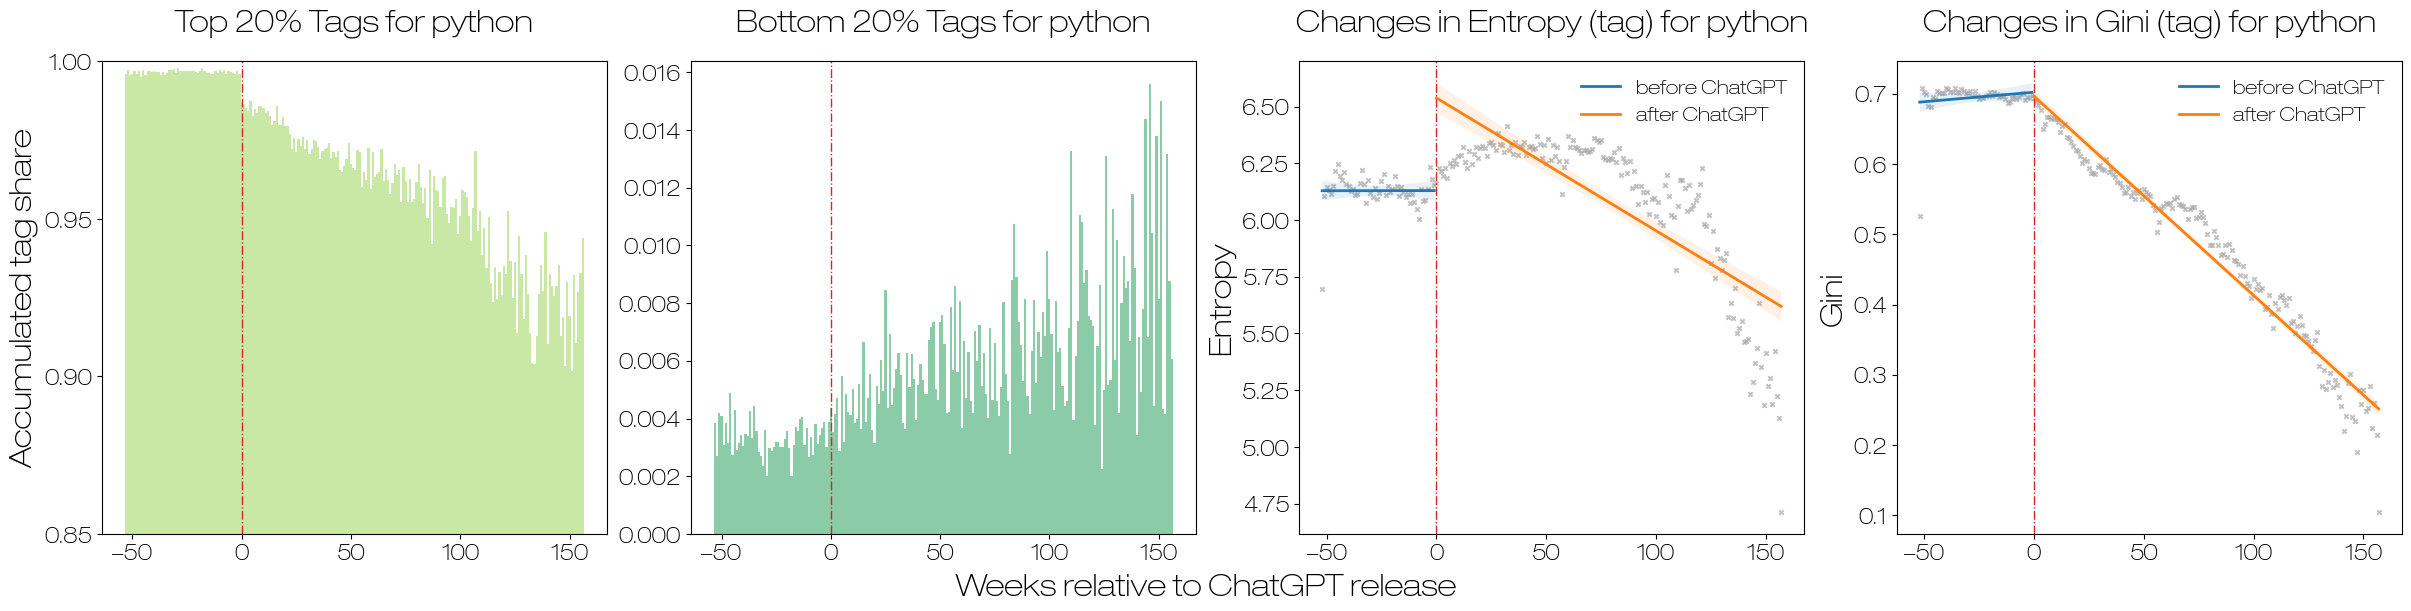

In [51]:
sharey = False ## 또는 sharey=False
sharex = True ## 또는 sharex=False

fig, axs = plt.subplots(1, 4, figsize = (24, 6), constrained_layout=True)
alpha_list = [0.6, 0.5]
color_list = ["#a6d96a", "#1a9850"]

for x, (title, proportion) in enumerate(proportion_dict.items()):
    rel_week = list(proportion['rel_week'])
    values = list(proportion['pct_pct'])
    
    axs[x].bar(rel_week, values, color=color_list[x], width=1.0, align='center', alpha=alpha_list[x]
    )
    axs[x].axvline(x=0, color='tab:red', linestyle='-.', linewidth=1)

    if x ==0 :
        axs[x].set_ylim(0.85, 1.0)
        axs[x].set_yticks(np.arange(0.85, 1.01, 0.05))


    axs[x].text(0.5, 1.05, f'{title} for {option_dict["selected_tags"]}',
            ha='center', va='bottom', fontsize=22, fontweight='bold', transform=axs[x].transAxes)

    axs[x].text(0.5, 1.00, "",
        ha='center', va='bottom', fontsize=15, transform=axs[x].transAxes)  
    axs[x].tick_params(axis='x', labelsize=16)
    axs[x].tick_params(axis='y', labelsize=16)


plot_regression(
    axs[2],
    entropy.values,
    f"Changes in Entropy (tag) for {option_dict['selected_tags']}",
    ylabel="Entropy"
)

plot_regression(
    axs[3],
    gini.values,
    f"Changes in Gini (tag) for {option_dict['selected_tags']}",
    ylabel="Gini"
)



axs[idx].tick_params(axis='x', labelsize=16)
axs[idx].tick_params(axis='y', labelsize=16)


axs[0].set_ylabel("Accumulated tag share", fontsize = 22)
axs[2].set_ylabel(f"Entropy", fontsize = 22)

fig.supxlabel("Weeks relative to ChatGPT release", fontsize=22) 
plt.savefig(f"{output_dir}C_Result_Fig2_2.png", dpi=300, bbox_inches='tight')
plt.show();

In [ ]:
tag_distribution_dict['cpp']

In [44]:
entropy.values

array([[-53.        ,   5.69738782],
       [-52.        ,   6.10764602],
       [-51.        ,   6.14531619],
       [-50.        ,   6.13425282],
       [-49.        ,   6.11454981],
       [-48.        ,   6.15149908],
       [-47.        ,   6.21776415],
       [-46.        ,   6.24833525],
       [-45.        ,   6.19250351],
       [-44.        ,   6.17578146],
       [-43.        ,   6.21251139],
       [-42.        ,   6.15997292],
       [-41.        ,   6.15128466],
       [-40.        ,   6.12731469],
       [-39.        ,   6.13577378],
       [-38.        ,   6.1091701 ],
       [-37.        ,   6.11417337],
       [-36.        ,   6.16088271],
       [-35.        ,   6.21879773],
       [-34.        ,   6.16067125],
       [-33.        ,   6.0732281 ],
       [-32.        ,   6.17459177],
       [-31.        ,   6.1187945 ],
       [-30.        ,   6.09920778],
       [-29.        ,   6.13932177],
       [-28.        ,   6.09296114],
       [-27.        ,   6.11779032],
 